# Stress Testing: WNBA Salary Valuation Models

1. Load processed train/test artifacts from `data/processed/`
2. Fit baseline models on 2021–2024 training data
3. Run stress tests:
   - **Test 1: Noise Injection** : Add Gaussian noise to numeric features; measure prediction stability
   - **Test 2: Extreme Stat Inputs** : Feed players with 1st and 99th percentile stats; check for nonsensical predictions
   - **Test 3: Contract Group Robustness** : Evaluate per-group (rookie / hardship / veteran / other) to diagnose where models break down
4. Log all results to `results/stress_test_log.csv`

## Imports and Configuration

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

NOISE_LEVELS = [0.01, 0.05, 0.10, 0.20]  # Fractions of feature std to inject as noise
N_NOISE_TRIALS = 30                        # Repeat each noise level N times for stability
RANDOM_SEED = 42

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent

processed_dir = repo / "data" / "processed"
results_dir = repo / "results"
results_dir.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## 1. Load Processed Data

In [4]:
X_train = pd.read_csv(processed_dir / "X_train_processed.csv")
y_train = pd.read_csv(processed_dir / "y_train.csv")["salary"]
X_test  = pd.read_csv(processed_dir / "X_test_2025_processed.csv")
y_test  = pd.read_csv(processed_dir / "y_test_2025.csv")["salary"]
lookup_test  = pd.read_csv(processed_dir / "player_lookup_test_2025.csv")
# feature_names = pd.read_csv(processed_dir / "feature_names.csv")["feature"].tolist()
feature_names = X_train.columns.tolist()

# Identify numeric features only (OHE columns are binary, skip them for noise/extreme tests)
ohe_cols  = [c for c in feature_names if c.startswith("group_")]
num_cols  = [c for c in feature_names if c not in ohe_cols]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Numeric features: {len(num_cols)}, OHE features: {len(ohe_cols)}")

X_train: (742, 25), X_test: (223, 25)
Numeric features: 20, OHE features: 5


## 2. Fit Baseline Models on Training Data

Same model set as `evaluation_result.ipynb`. Fit once on 2021–2024; reuse across all stress tests.

In [5]:
models = {
    "DummyRegressor":        DummyRegressor(strategy="mean"),
    "LinearRegression":      LinearRegression(),
    "Ridge":                 Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5, random_state=26
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    holdout_rmse = root_mean_squared_error(y_test, model.predict(X_test))
    print(f"{name}: holdout RMSE = ${holdout_rmse:,.0f}")

DummyRegressor: holdout RMSE = $68,540
LinearRegression: holdout RMSE = $45,424
Ridge: holdout RMSE = $44,981
RandomForestRegressor: holdout RMSE = $41,513


## 3. Stress Test 1: Noise Injection

**What we are checking:** Do salary predictions stay stable when we add small random perturbations to the input features?

A robust model should produce predictions that shift proportionally to the noise level. Wild swings at low noise levels (1–5%) would indicate fragility.

**Method:** For each noise level, add Gaussian noise scaled to that fraction of each feature's standard deviation. Repeat 30 trials per level and record the mean absolute shift in predicted salary versus the clean baseline.

In [6]:
rng = np.random.default_rng(RANDOM_SEED)
feature_stds = X_test[num_cols].std()

noise_rows = []

for model_name, model in models.items():
    baseline_preds = model.predict(X_test)

    for noise_level in NOISE_LEVELS:
        trial_shifts = []

        for _ in range(N_NOISE_TRIALS):
            X_noisy = X_test.copy()
            noise = rng.normal(
                loc=0,
                scale=(feature_stds * noise_level).values,
                size=(len(X_test), len(num_cols)),
            )
            X_noisy[num_cols] += noise

            noisy_preds = model.predict(X_noisy)
            mean_shift = np.abs(noisy_preds - baseline_preds).mean()
            trial_shifts.append(mean_shift)

        noise_rows.append({
            "test_name":         "noise_injection",
            "model":             model_name,
            "noise_level_pct":   noise_level * 100,
            "n_trials":          N_NOISE_TRIALS,
            "mean_pred_shift":   np.mean(trial_shifts),
            "max_pred_shift":    np.max(trial_shifts),
            "std_pred_shift":    np.std(trial_shifts),
            "generated_at":      pd.Timestamp.now().isoformat(timespec="seconds"),
        })

noise_df = pd.DataFrame(noise_rows)
display(noise_df)

,test_name,model,noise_level_pct,n_trials,mean_pred_shift,max_pred_shift,std_pred_shift,generated_at
0,noise_injection,DummyRegressor,1.0,30,0.000000,0.000000,0.000000,2026-06-21T14:02:20
1,noise_injection,DummyRegressor,5.0,30,0.000000,0.000000,0.000000,2026-06-21T14:02:20
2,noise_injection,DummyRegressor,10.0,30,0.000000,0.000000,0.000000,2026-06-21T14:02:20
3,noise_injection,DummyRegressor,20.0,30,0.000000,0.000000,0.000000,2026-06-21T14:02:20
4,noise_injection,LinearRegression,1.0,30,1026.998670,1093.144861,40.661924,2026-06-21T14:02:20
5,noise_injection,LinearRegression,5.0,30,5172.270217,5679.947004,252.267542,2026-06-21T14:02:20
6,noise_injection,LinearRegression,10.0,30,10414.562814,11610.456952,508.731421,2026-06-21T14:02:20
7,noise_injection,LinearRegression,20.0,30,20212.290774,22450.529633,923.108199,2026-06-21T14:02:20
8,noise_injection,Ridge,1.0,30,830.145264,944.995579,42.684473,2026-06-21T14:02:20
9,noise_injection,Ridge,5.0,30,4197.397056,4604.744791,177.009185,2026-06-21T14:02:20


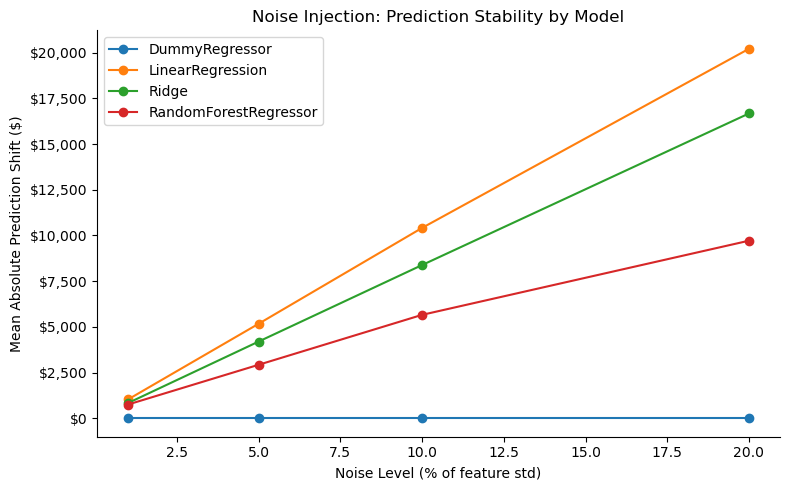

In [7]:
# Plot: mean prediction shift vs. noise level, one line per model
fig, ax = plt.subplots(figsize=(8, 5))

for model_name in models:
    subset = noise_df[noise_df["model"] == model_name]
    ax.plot(
        subset["noise_level_pct"],
        subset["mean_pred_shift"],
        marker="o",
        label=model_name,
    )

ax.set_xlabel("Noise Level (% of feature std)")
ax.set_ylabel("Mean Absolute Prediction Shift ($)")
ax.set_title("Noise Injection: Prediction Stability by Model")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

## 4. Stress Test 2: Extreme Stat Inputs

**What we are checking:** Does the model produce sensible salary predictions for extreme players — someone with all stats at the 1st percentile (fringe player) or all at the 99th (superstar)?

We also construct a mixed-extreme row where offensive stats are maxed out but efficiency stats are minimal, to check for illogical combinations.

**What counts as sensible:** Predictions should be within or near the observed salary range in the training data (~$7k–$250k). Predictions below zero or above ~$500k are flagged.

In [8]:
# Build extreme rows using train distribution (not test, we don't want to peek at 2025)
p01 = X_train[num_cols].quantile(0.01)
p99 = X_train[num_cols].quantile(0.99)

# For OHE group columns, use a neutral "other" encoding (all zeros, unknown group catches this)
ohe_neutral = pd.Series(0, index=ohe_cols)

def make_extreme_row(num_vals, label):
    row = pd.concat([num_vals, ohe_neutral])
    return row.reindex(feature_names).to_frame().T.reset_index(drop=True), label

# Mixed extreme: high volume, low efficiency
mixed = p99.copy()
for col in ["avail_rate", "start_rate"]:
    if col in mixed.index:
        mixed[col] = p01[col]

extreme_inputs = [
    make_extreme_row(p01, "p01_all_features"),
    make_extreme_row(p99, "p99_all_features"),
    make_extreme_row(mixed, "p99_volume_p01_availability"),
]

# Salary bounds observed in training data
salary_min = y_train.min()
salary_max = y_train.max()
extreme_rows = []

for X_extreme, label in extreme_inputs:
    for model_name, model in models.items():
        pred = model.predict(X_extreme)[0]
        in_range = salary_min <= pred <= salary_max * 2  # Allow 2x max as generous upper bound
        extreme_rows.append({
            "test_name":          "extreme_stat_inputs",
            "model":              model_name,
            "input_profile":      label,
            "predicted_salary":   pred,
            "train_salary_min":   salary_min,
            "train_salary_max":   salary_max,
            "within_range":       in_range,
            "generated_at":       pd.Timestamp.now().isoformat(timespec="seconds"),
        })

extreme_df = pd.DataFrame(extreme_rows)
extreme_df["predicted_salary"] = extreme_df["predicted_salary"].map("${:,.0f}".format)
display(extreme_df)

,test_name,model,input_profile,predicted_salary,train_salary_min,train_salary_max,within_range,generated_at
0,extreme_stat_inputs,DummyRegressor,p01_all_features,"$87,598",464,242154,True,2026-06-21T14:02:22
1,extreme_stat_inputs,LinearRegression,p01_all_features,"$17,830",464,242154,True,2026-06-21T14:02:22
2,extreme_stat_inputs,Ridge,p01_all_features,"$18,045",464,242154,True,2026-06-21T14:02:22
3,extreme_stat_inputs,RandomForestRegressor,p01_all_features,"$31,606",464,242154,True,2026-06-21T14:02:22
4,extreme_stat_inputs,DummyRegressor,p99_all_features,"$87,598",464,242154,True,2026-06-21T14:02:22
5,extreme_stat_inputs,LinearRegression,p99_all_features,"$100,459",464,242154,True,2026-06-21T14:02:22
6,extreme_stat_inputs,Ridge,p99_all_features,"$105,988",464,242154,True,2026-06-21T14:02:22
7,extreme_stat_inputs,RandomForestRegressor,p99_all_features,"$186,368",464,242154,True,2026-06-21T14:02:22
8,extreme_stat_inputs,DummyRegressor,p99_volume_p01_availability,"$87,598",464,242154,True,2026-06-21T14:02:22
9,extreme_stat_inputs,LinearRegression,p99_volume_p01_availability,"$60,268",464,242154,True,2026-06-21T14:02:22


## 5. Stress Test 3: Contract Group Robustness

**What we are checking:** Does model performance degrade significantly for specific contract groups?

We know from `KPI_baseline.ipynb` that MAPE blows up on rookie and hardship contracts. This test measures RMSE and MAE per group on the 2025 holdout to confirm which groups each model handles well and which it fails on.

This is important context for the written summary: a model may look good overall while being badly miscalibrated for a specific tier.

In [9]:
group_rows = []

for model_name, model in models.items():
    preds = model.predict(X_test)
    results_with_group = lookup_test.copy()
    results_with_group["predicted_salary"] = preds
    results_with_group["actual_salary"] = y_test.values

    for group, grp_df in results_with_group.groupby("group"):
        if len(grp_df) < 2:
            continue  # Skip groups too small for meaningful metrics

        rmse = root_mean_squared_error(grp_df["actual_salary"], grp_df["predicted_salary"])
        mae  = mean_absolute_error(grp_df["actual_salary"], grp_df["predicted_salary"])
        median_actual = grp_df["actual_salary"].median()

        group_rows.append({
            "test_name":        "contract_group_robustness",
            "model":            model_name,
            "group":            group,
            "n_players":        len(grp_df),
            "rmse":             rmse,
            "mae":              mae,
            "median_actual":    median_actual,
            "mae_as_pct_median": mae / median_actual * 100 if median_actual > 0 else np.nan,
            "generated_at":     pd.Timestamp.now().isoformat(timespec="seconds"),
        })

group_df = pd.DataFrame(group_rows)
display(group_df.sort_values(["model", "rmse"], ascending=[True, False]))

,test_name,model,group,n_players,rmse,mae,median_actual,mae_as_pct_median,generated_at
4,contract_group_robustness,DummyRegressor,veteran,133,76888.917419,65833.998977,78831.0,83.512830,2026-06-21T14:02:22
1,contract_group_robustness,DummyRegressor,hardship,20,75081.961777,70234.921833,6630.5,1059.270369,2026-06-21T14:02:22
3,contract_group_robustness,DummyRegressor,unknown,17,73061.574299,53701.268987,78066.0,68.789574,2026-06-21T14:02:22
0,contract_group_robustness,DummyRegressor,controlled,13,45819.405721,35060.355484,66079.0,53.058242,2026-06-21T14:02:22
2,contract_group_robustness,DummyRegressor,rookie,40,27622.394647,17225.168194,75276.0,22.882683,2026-06-21T14:02:22
9,contract_group_robustness,LinearRegression,veteran,133,52320.142756,41388.360368,78831.0,52.502645,2026-06-21T14:02:22
8,contract_group_robustness,LinearRegression,unknown,17,49087.322444,42602.988756,78066.0,54.573039,2026-06-21T14:02:22
5,contract_group_robustness,LinearRegression,controlled,13,33943.972199,26872.483118,66079.0,40.667206,2026-06-21T14:02:22
6,contract_group_robustness,LinearRegression,hardship,20,31367.011072,24336.067504,6630.5,367.032162,2026-06-21T14:02:22
7,contract_group_robustness,LinearRegression,rookie,40,22598.947289,15921.379782,75276.0,21.150672,2026-06-21T14:02:22


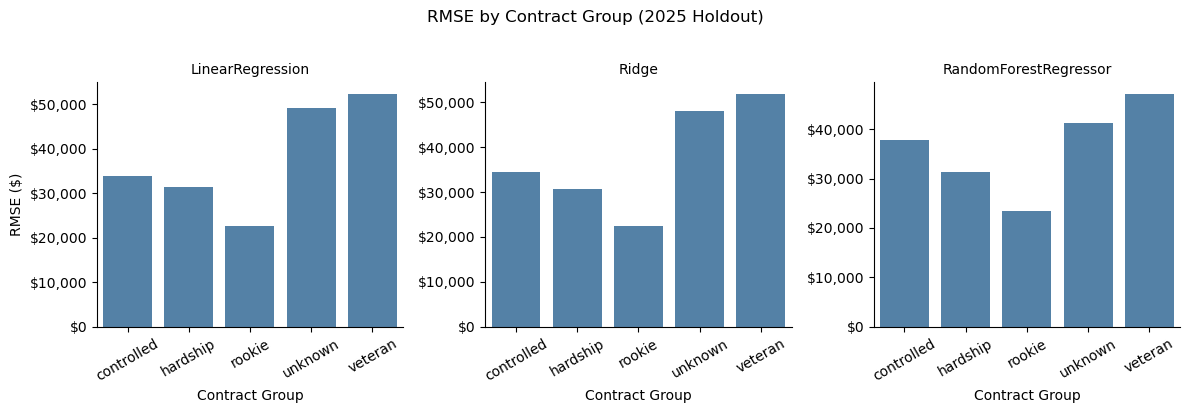

In [10]:
# Plot: RMSE by contract group, faceted by model
plot_df = group_df[group_df["model"] != "DummyRegressor"].copy()

g = sns.FacetGrid(plot_df, col="model", col_wrap=3, height=4, sharey=False)
g.map_dataframe(
    sns.barplot,
    x="group",
    y="rmse",
    order=sorted(plot_df["group"].unique()),
    color="steelblue",
)
g.set_axis_labels("Contract Group", "RMSE ($)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    for label in ax.get_xticklabels():
        label.set_rotation(30)
g.figure.suptitle("RMSE by Contract Group (2025 Holdout)", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

## 6. Save Stress Test Log

All results are combined into a single log file saved to `results/stress_test_log.csv`.
Each row includes a `test_name` column so results can be filtered by test type downstream.

In [11]:
# Normalize extreme_df before concat (undo the formatting applied for display)
extreme_df_raw = pd.DataFrame(extreme_rows)  # Re-use the unformatted version

log = pd.concat(
    [noise_df, extreme_df_raw, group_df],
    ignore_index=True,
    sort=False,
)

log_path = results_dir / "stress_test_log.csv"
log.to_csv(log_path, index=False)

print(f"Stress test log saved: {log_path}")
print(f"Total rows logged: {len(log)}")
print(f"Tests covered: {log['test_name'].unique().tolist()}")

Stress test log saved: /Users/aklima/GitHub/summer26-wnba-player-valuation/results/stress_test_log.csv
Total rows logged: 48
Tests covered: ['noise_injection', 'extreme_stat_inputs', 'contract_group_robustness']


## 7. Stress Test Summary

**Feature set:** 21 features (20 numeric + `group` OHE'd into 5 dummies = 25 columns total), including contract interaction features `ws_vet`, `ws_hardship`, and `pts_hardship` that was added later.

**Holdout RMSE (2025 test set):**
| Model | RMSE |
|---|---|
| DummyRegressor | $68,540 |
| LinearRegression | $45,424 |
| Ridge | $44,981 |
| RandomForestRegressor | $41,513 |

---

### Test 1: Noise Injection

All models respond to noise proportionally. Prediction shift scales linearly with noise level and no model exhibits sudden instability. Ridge is the most stable (20% noise -> $16,675 mean shift), marginally better than LinearRegression ($20,212). RandomForest is the least sensitive at high noise levels ($9,714 mean shift at 20% noise), consistent with tree-based models being less affected by small continuous perturbations since predictions only change when noise crosses a decision boundary. DummyRegressor is unaffected by noise by construction.

**Conclusion:** All models pass the noise injection test. No fragility concerns.

---

### Test 2: Extreme Stat Inputs

All models produce predictions within the observed training salary range ($464–$242,154) for all three input profiles:

| Input Profile | LinearRegression | Ridge | RandomForest |
|---|---|---|---|
| p01 (fringe player) | $17,830 | $18,045 | $31,606 |
| p99 (superstar) | $100,459 | $105,988 | $186,368 |
| p99 volume / p01 availability | $60,268 | $79,173 | $113,080 |

RandomForest under-predicts the p99 superstar ceiling ($186k vs actual max of $242k), consistent with the known tendency of tree models to truncate at extremes. The mixed-extreme profile correctly receives a lower prediction than the pure p99 profile across all models, confirming the availability features (`avail_rate`, `start_rate`) are functioning as intended.

**Conclusion:** All models pass the extreme input test. No out-of-range or nonsensical predictions.

---

### Test 3: Contract Group Robustness

Performance varies significantly by contract group, reflecting fundamental differences in how salaries are set under the CBA:

| Group | n | Median Actual | RF MAE | MAE as % of Median |
|---|---|---|---|---|
| rookie | 40 | $75,276 | $13,069 | 17% |
| controlled | 13 | $66,079 | $28,884 | 44% |
| unknown | 17 | $78,066 | $31,247 | 40% |
| veteran | 133 | $78,831 | $37,273 | 47% |
| hardship | 20 | $6,631 | $20,820 | **314%** |

The three contract groups fail for structurally different reasons:

**Hardship (314% MAE/median):** Hardship contracts are CBA-fixed at a league minimum ($6.6k) regardless of performance. No combination of features can recover this relationship. The salary is determined entirely by the CBA, not by what the player does on court. Adding `ws_hardship` and `pts_hardship` had minimal effect (down from 367% to 314% for LinearRegression). Hardship contracts should be excluded from aggregate evaluation metrics as they represent a separate salary regime.

**Veteran (47% MAE/median):** Veteran salaries are market-driven and influenced heavily by factors outside the current feature set: years of experience, previous contract value, injury history, all-star appearances, and off-court negotiation. The addition of `ws_vet` did not meaningfully improve veteran predictions, confirming the missing signal is not about the shape of the stats-to-salary relationship but about missing contextual variables entirely.

**Rookie (17% MAE/median):** Rookie salaries are partially CBA-structured (scale-based by experience tier), which makes them more predictable from stats. This group is the best-predicted across all models, and the `pts_rookie` and `ws_rookie` interaction features are contributing effectively.

**Conclusion:** The model works well for rookies, acceptably for controlled and unknown groups, and poorly for veterans and hardship players, but for different structural reasons. Hardship is a CBA artifact. Veteran error reflects missing features. Neither failure indicates a broken model.

---

### Overall Findings

- **Stability:** All models are robust to input noise and extreme stat profiles.
- **Sensibility:** No model produces out-of-range or negative predictions under any stress condition.
- **Best model under stress:** RandomForest, lowest holdout RMSE ($41,513), most stable under high noise, best MAE/median across all contract groups.
- **Known limitation:** Three contract groups fail for structurally different reasons. Hardship contracts are CBA-fixed and should be excluded from primary evaluation. Veteran prediction error reflects missing contextual features (experience, market value, negotiation) that are not available in the current dataset.
